# Model Sentimen Ulasan

Notebook ini melatih model yang menebak apakah sebuah ulasan bernada positif atau negatif, memakai data dari `05_data_prep_ulasan.ipynb`.

Tantangan utamanya adalah ketidakseimbangan kelas: hanya 2,4% ulasan yang negatif. Karena itu model dinilai terutama dari kemampuannya mengenali ulasan negatif, bukan dari akurasi keseluruhan.

Urutan langkah:

1. Membagi data menjadi data latih dan data uji
2. Membuat model patokan (baseline)
3. Model pertama: TF-IDF dan Logistic Regression
4. Menangani ketidakseimbangan kelas
5. Mencari pengaturan terbaik dengan GridSearchCV
6. Menggeser ambang keputusan
7. Evaluasi akhir di data uji
8. Kata yang paling berpengaruh
9. Analisis kesalahan
10. Kenapa skornya mentok
11. Menyimpan model

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    StratifiedKFold,
    TunedThresholdClassifierCV,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.metrics import precision_recall_curve
from sklearn.pipeline import Pipeline

In [2]:
# Gaya grafik, sama dengan notebook sebelumnya
BIRU = "#2a78d6"
ORANYE = "#eb6834"
ABU = "#c8c6bf"
TEKS = "#52514e"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#8a8983",
    "axes.labelcolor": TEKS,
    "xtick.color": TEKS,
    "ytick.color": TEKS,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
})

In [3]:
df = pd.read_csv("../Dataset/processed/ulasan_bersih.csv")
print(df.shape)
df["label"].value_counts()

(38585, 9)


label
positif    37663
negatif      922
Name: count, dtype: int64

## 1. Bagi data menjadi data latih dan data uji

Data dibagi dua:

- Data latih (80%): dipakai untuk melatih model dan memilih pengaturan terbaik.
- Data uji (20%): disimpan dan baru dipakai sekali di akhir, untuk mengukur seberapa baik model bekerja pada ulasan yang belum pernah dilihatnya.

### Kenapa dibagi per produk, bukan acak?

Ulasan untuk produk yang sama sering memakai kata yang khas untuk produk itu, misalnya nama merek atau keluhan yang sama ("baterai drop", "speaker mati sebelah"). Kalau ulasan dari satu produk tersebar di data latih dan data uji, model sebagian mengenali produknya, bukan nada ulasannya, sehingga skornya terlihat lebih bagus dari kenyataan. Padahal di dashboard, model dipakai untuk menilai ulasan yang belum pernah dilihatnya, termasuk dari produk lain.

Karena itu semua ulasan dari satu produk dimasukkan ke data latih saja atau data uji saja, sama seperti di notebook 08. Pembaginya adalah `StratifiedGroupKFold`:

- *Group*: satu produk selalu berada di satu sisi saja.
- *Stratified*: porsi ulasan negatif dijaga tetap mirip, sekitar 2,4%, di kedua sisi. Tanpa ini, bisa saja data uji kebetulan hanya berisi sedikit sekali ulasan negatif.

Data dibagi menjadi 5 lipatan, lalu satu lipatan dipakai sebagai data uji (20%). `random_state=42` membuat pembagiannya selalu sama setiap kali notebook dijalankan. Cross-validation di data latih juga dibagi per produk dengan cara yang sama.

Versi awal notebook ini membagi data secara acak. Selisih skor kedua cara itu dibahas di bagian 10.

### Kenapa persiapan data untuk model dilakukan setelah split?

Di notebook 05, teks sudah dibersihkan sebelum data dibagi. Itu aman karena setiap ulasan dibersihkan sendiri-sendiri dengan aturan tetap. Ulasan lain tidak memengaruhi hasilnya.

TF-IDF berbeda. TF-IDF "belajar" dari data: kosakatanya dan bobot setiap kata dihitung dari seluruh ulasan yang diberikan kepadanya. Kalau TF-IDF dilatih dengan seluruh data sebelum dibagi, informasi dari data uji ikut bocor ke model. Akibatnya skor data uji terlihat lebih bagus dari kemampuan model yang sebenarnya. Kebocoran seperti ini disebut data leakage.

Cara mencegahnya adalah menggabungkan TF-IDF dan model dalam satu `Pipeline`. Dengan pipeline, TF-IDF selalu dilatih hanya dengan data latih, termasuk di dalam setiap lipatan cross-validation.

In [4]:
X = df["teks_bersih"]
y = df["label"]
produk = df["id_produk"]

pembagi = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
idx_latih, idx_uji = next(pembagi.split(X, y, groups=produk))

X_latih, X_uji = X.iloc[idx_latih], X.iloc[idx_uji]
y_latih, y_uji = y.iloc[idx_latih], y.iloc[idx_uji]
produk_latih = produk.iloc[idx_latih]

print("Data latih:", len(X_latih), "| negatif:", (y_latih == "negatif").sum(), f"({(y_latih == 'negatif').mean():.1%})")
print("Data uji  :", len(X_uji), "| negatif:", (y_uji == "negatif").sum(), f"({(y_uji == 'negatif').mean():.1%})")
print("Produk yang ada di keduanya:", len(set(produk_latih) & set(produk.iloc[idx_uji])))

Data latih: 30869 | negatif: 738 (2.4%)
Data uji  : 7716 | negatif: 184 (2.4%)
Produk yang ada di keduanya: 0


## 2. Model patokan (baseline)

Model patokan adalah model paling sederhana yang bisa dibuat. Di sini modelnya selalu menebak label yang paling sering muncul, yaitu "positif". Model apa pun yang dibuat setelah ini harus lebih baik dari patokan ini.

In [5]:
patokan = DummyClassifier(strategy="most_frequent").fit(X_latih, y_latih)
print(classification_report(y_uji, patokan.predict(X_uji), digits=3, zero_division=0))

              precision    recall  f1-score   support

     negatif      0.000     0.000     0.000       184
     positif      0.976     1.000     0.988      7532

    accuracy                          0.976      7716
   macro avg      0.488     0.500     0.494      7716
weighted avg      0.953     0.976     0.964      7716



Model patokan mendapat akurasi 97,6% tanpa belajar apa pun, tetapi tidak menemukan satu pun ulasan negatif. Inilah alasan akurasi tidak bisa dipakai sebagai ukuran utama.

Tiga ukuran yang dipakai di notebook ini, semuanya untuk kelas negatif:

- Precision: dari semua ulasan yang ditebak negatif, berapa persen yang benar-benar negatif. Precision rendah berarti banyak alarm palsu.
- Recall: dari semua ulasan yang benar-benar negatif, berapa persen yang berhasil ditemukan. Recall rendah berarti banyak keluhan yang terlewat.
- F1: gabungan precision dan recall (rata-rata harmonik). Nilainya hanya tinggi kalau keduanya tinggi. F1 dipakai sebagai ukuran utama untuk memilih model.

## 3. Model pertama: TF-IDF dan Logistic Regression

Model butuh angka, bukan teks. TF-IDF mengubah setiap ulasan menjadi deretan angka, satu angka untuk setiap kata di kosakata:

- TF (term frequency): seberapa sering kata muncul di ulasan itu.
- IDF (inverse document frequency): kata yang muncul di hampir semua ulasan, seperti "barang", diberi bobot kecil. Kata yang jarang dan spesifik, seperti "retur", diberi bobot besar.

Pengaturan yang dipakai:

- `ngram_range=(1, 2)`: selain kata tunggal, pasangan dua kata juga dihitung. Jadi "tidak sesuai" dikenali sebagai satu kesatuan, bukan hanya "tidak" dan "sesuai" secara terpisah.
- `min_df=2`: kata yang hanya muncul di satu ulasan diabaikan, karena biasanya salah ketik.
- `sublinear_tf=True`: kata yang diulang berkali-kali di satu ulasan tidak diberi bobot berlebihan.

Logistic Regression lalu mempelajari bobot untuk setiap kata. Kata dengan bobot negatif mendorong tebakan ke arah "negatif", dan sebaliknya. Model ini sederhana, cepat, dan bobotnya mudah dibaca, sehingga cocok sebagai model pertama.

`n_jobs=2` di kode berarti proses dijalankan paralel di 2 core CPU. Angka ini sengaja dibatasi. Dengan `n_jobs=-1` (semua core), setiap proses memuat salinan data sendiri, sehingga pemakaian RAM berlipat dan laptop bisa kehabisan memori.

Model dinilai dengan cross-validation 5 lipatan di data latih. Data latih dibagi menjadi 5 bagian, lagi-lagi per produk. Model dilatih 5 kali, dan setiap kali satu bagian yang berbeda dipakai untuk menilai. Skor akhirnya adalah rata-rata kelima penilaian itu. Cara ini lebih stabil daripada satu kali penilaian, dan data uji tetap tidak tersentuh.

Lipatannya dibuat sekali lalu disimpan sebagai daftar (`list`), supaya semua langkah di bawah, dari GridSearchCV sampai penyetelan ambang, memakai pembagian yang persis sama.

In [6]:
f1_negatif = make_scorer(f1_score, pos_label="negatif")
ukuran = {
    "precision": make_scorer(precision_score, pos_label="negatif", zero_division=0),
    "recall": make_scorer(recall_score, pos_label="negatif"),
    "f1": f1_negatif,
}
# Lipatan cross-validation juga dibagi per produk
cv = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_latih, y_latih, groups=produk_latih))


def buat_pipeline(**pengaturan_model):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("model", LogisticRegression(max_iter=3000, **pengaturan_model)),
    ])


def nilai_cv(model):
    hasil = cross_validate(model, X_latih, y_latih, cv=cv, scoring=ukuran, n_jobs=2)
    return {k: hasil[f"test_{k}"].mean() for k in ukuran}


perbandingan = {}
perbandingan["Logistic Regression standar"] = nilai_cv(buat_pipeline())
pd.DataFrame(perbandingan).T.round(3)

,precision,recall,f1
Logistic Regression standar,0.836,0.229,0.358


Precision-nya tinggi, tetapi recall-nya hanya sekitar 23%. Model jarang salah ketika menebak negatif, tetapi hampir 4 dari 5 ulasan negatif terlewat. Penyebabnya, model hanya melihat sedikit contoh negatif, sehingga lebih "aman" baginya untuk hampir selalu menebak positif.

## 4. Menangani ketidakseimbangan kelas

`class_weight="balanced"` membuat kesalahan pada ulasan negatif dihitung jauh lebih berat saat model belajar, sebanding dengan kelangkaannya. Di data ini, satu ulasan negatif bobotnya sekitar 40 kali lipat ulasan positif. Hasilnya, model lebih berani menebak negatif.

Cara lain yang sering dipakai adalah oversampling, yaitu memperbanyak contoh negatif dengan menyalinnya atau membuat contoh buatan (misalnya SMOTE). Untuk Logistic Regression, `class_weight` memberi efek yang mirip tanpa perlu mengubah data, jadi cara itu yang dipakai di sini.

In [7]:
perbandingan["Dengan class_weight balanced"] = nilai_cv(buat_pipeline(class_weight="balanced"))
pd.DataFrame(perbandingan).T.round(3)

,precision,recall,f1
Logistic Regression standar,0.836,0.229,0.358
Dengan class_weight balanced,0.382,0.833,0.523


Recall naik tajam menjadi sekitar 83%, tetapi precision turun menjadi sekitar 38%. Model sekarang menemukan sebagian besar ulasan negatif, tetapi juga sering salah menandai ulasan positif sebagai negatif. Precision dan recall hampir selalu tarik-menarik seperti ini. F1 tetap naik, dari sekitar 0,36 menjadi 0,52.

## 5. Mencari pengaturan terbaik dengan GridSearchCV

Logistic Regression punya pengaturan `C`, yang mengatur seberapa bebas model mengikuti data latih:

- `C` kecil: model dibatasi lebih ketat (regularisasi kuat). Model lebih sederhana, tetapi bisa terlalu kaku.
- `C` besar: model lebih bebas memberi bobot besar pada kata-kata tertentu. Model lebih detail, tetapi berisiko menghafal data latih (overfitting).

GridSearchCV mencoba setiap kombinasi `C` dan `class_weight`, menilai masing-masing dengan cross-validation, lalu memilih kombinasi dengan F1 tertinggi.

In [8]:
grid = GridSearchCV(
    buat_pipeline(),
    param_grid={
        "model__C": [0.3, 1, 3, 10, 30],
        "model__class_weight": [None, "balanced"],
    },
    scoring=f1_negatif,
    cv=cv,
    n_jobs=2,
)
grid.fit(X_latih, y_latih)

hasil_grid = pd.DataFrame(grid.cv_results_)[["param_model__C", "param_model__class_weight", "mean_test_score"]]
hasil_grid = hasil_grid.rename(columns={
    "param_model__C": "C",
    "param_model__class_weight": "class_weight",
    "mean_test_score": "f1_cv",
})
hasil_grid["class_weight"] = hasil_grid["class_weight"].fillna("tidak ada")
print("Pengaturan terbaik:", grid.best_params_)
hasil_grid.sort_values("f1_cv", ascending=False).round(3)

Pengaturan terbaik: {'model__C': 30, 'model__class_weight': None}


,C,class_weight,f1_cv
8,30.0,tidak ada,0.590
9,30.0,balanced,0.585
7,10.0,balanced,0.581
5,3.0,balanced,0.577
6,10.0,tidak ada,0.562
3,1.0,balanced,0.523
4,3.0,tidak ada,0.483
1,0.3,balanced,0.445
2,1.0,tidak ada,0.358
0,0.3,tidak ada,0.087


In [9]:
C_terbaik = grid.best_params_["model__C"]
cw_terbaik = grid.best_params_["model__class_weight"]
perbandingan["GridSearchCV"] = nilai_cv(buat_pipeline(C=C_terbaik, class_weight=cw_terbaik))
pd.DataFrame(perbandingan).T.round(3)

,precision,recall,f1
Logistic Regression standar,0.836,0.229,0.358
Dengan class_weight balanced,0.382,0.833,0.523
GridSearchCV,0.777,0.481,0.590


Pengaturan terbaik adalah `C=30` tanpa `class_weight`, dengan F1 sekitar 0,59. Nilai 30 adalah nilai terbesar di grid, jadi wajar kalau muncul pertanyaan apakah `C` yang lebih besar lagi akan lebih baik. Saat diuji terpisah, `C` 100, 300, dan 1000 memberi F1 yang sedikit lebih rendah, jadi 30 sudah berada di puncaknya.

Model dengan `C` besar lebih berani memakai kata-kata yang spesifik, sehingga recall-nya naik tanpa mengorbankan precision sebanyak `class_weight`.

## 6. Menggeser ambang keputusan

Logistic Regression sebenarnya menghasilkan peluang, misalnya "peluang ulasan ini negatif = 0,3". Secara bawaan, ulasan ditebak negatif kalau peluangnya minimal 0,5. Angka 0,5 ini disebut ambang (threshold), dan tidak harus 0,5.

Untuk kelas yang langka, peluang negatif yang dihasilkan model jarang mencapai 0,5 walaupun ulasannya memang negatif. Menurunkan ambang membuat model lebih mudah menebak negatif (recall naik, precision turun). Menaikkan ambang berlaku sebaliknya.

`TunedThresholdClassifierCV` mencari ambang yang menghasilkan F1 tertinggi. Pencariannya juga memakai cross-validation di data latih, jadi data uji tetap tidak tersentuh. Ambang yang ditemukan tersimpan di dalam model, sehingga dashboard nanti otomatis memakai ambang yang sama.

In [10]:
model_akhir = TunedThresholdClassifierCV(
    buat_pipeline(C=C_terbaik, class_weight=cw_terbaik),
    scoring=f1_negatif,
    cv=cv,
    n_jobs=2,
)
model_akhir.fit(X_latih, y_latih)

print(f"Ambang terbaik: {model_akhir.best_threshold_:.3f}")
print(f"F1 cross-validation dengan ambang ini: {model_akhir.best_score_:.3f}")

Ambang terbaik: 0.303
F1 cross-validation dengan ambang ini: 0.623


Untuk membandingkan dengan langkah sebelumnya, precision dan recall pada ambang ini dihitung dari prediksi cross-validation di data latih. Setiap ulasan di data latih diberi peluang negatif oleh model yang tidak melihat ulasan itu saat dilatih, lalu ambang yang sudah ditemukan diterapkan.

In [11]:
peluang_cv = cross_val_predict(
    buat_pipeline(C=C_terbaik, class_weight=cw_terbaik),
    X_latih, y_latih, cv=cv, method="predict_proba", n_jobs=2,
)
kolom_negatif = list(model_akhir.classes_).index("negatif")
tebakan_cv = np.where(peluang_cv[:, kolom_negatif] >= model_akhir.best_threshold_, "negatif", "positif")

perbandingan["Ambang disesuaikan"] = {
    "precision": precision_score(y_latih, tebakan_cv, pos_label="negatif"),
    "recall": recall_score(y_latih, tebakan_cv, pos_label="negatif"),
    "f1": f1_score(y_latih, tebakan_cv, pos_label="negatif"),
}
tabel = pd.DataFrame(perbandingan).T
tabel.round(3)

,precision,recall,f1
Logistic Regression standar,0.836,0.229,0.358
Dengan class_weight balanced,0.382,0.833,0.523
GridSearchCV,0.777,0.481,0.590
Ambang disesuaikan,0.675,0.583,0.625


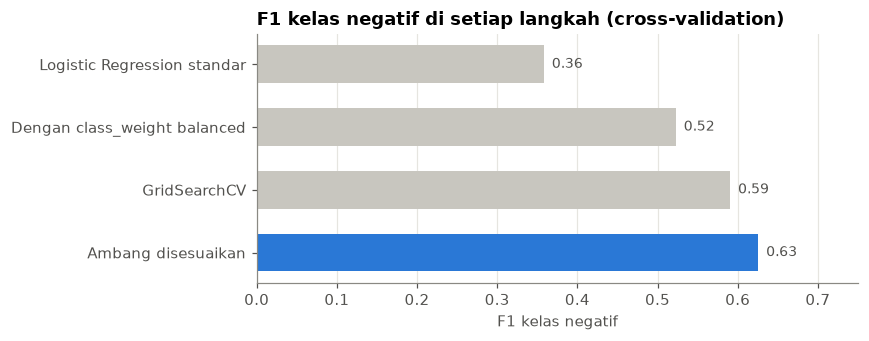

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.2))
urut = tabel["f1"]
warna = [ABU] * (len(urut) - 1) + [BIRU]
ax.barh(urut.index[::-1], urut.values[::-1], color=warna[::-1], height=0.6)
for y, v in enumerate(urut.values[::-1]):
    ax.text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=9, color=TEKS)
ax.set_xlim(0, 0.75)
ax.set_title("F1 kelas negatif di setiap langkah (cross-validation)")
ax.set_xlabel("F1 kelas negatif")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Ambang yang ditemukan sekitar 0,30 untuk peluang negatif. Artinya, ulasan sudah ditebak negatif kalau model memberi peluang negatif sekitar 30% atau lebih. Dengan ambang ini, F1 cross-validation naik menjadi sekitar 0,62, dengan precision dan recall yang lebih seimbang.

Pemilihan ambang juga bisa disesuaikan dengan kebutuhan bisnis. Kalau tujuannya memastikan tidak ada keluhan yang terlewat, misalnya untuk tim layanan pelanggan, ambang bisa diturunkan lagi supaya recall lebih tinggi, dengan konsekuensi lebih banyak alarm palsu.

## 7. Evaluasi akhir di data uji

Semua keputusan (model, `C`, `class_weight`, dan ambang) sudah dibuat hanya dengan data latih. Sekarang model dinilai sekali di data uji.

Data uji tidak boleh dipakai untuk memilih model. Kalau beberapa model dicoba lalu dipilih yang skornya paling bagus di data uji, skor itu tidak lagi jujur, karena pilihannya sudah disesuaikan dengan data uji.

In [13]:
prediksi_uji = model_akhir.predict(X_uji)
print(classification_report(y_uji, prediksi_uji, digits=3))

              precision    recall  f1-score   support

     negatif      0.629     0.516     0.567       184
     positif      0.988     0.993     0.990      7532

    accuracy                          0.981      7716
   macro avg      0.809     0.754     0.779      7716
weighted avg      0.980     0.981     0.980      7716



Data uji hanya berisi 184 ulasan negatif, jadi skor di atas bisa bergeser beberapa poin kalau isi data ujinya sedikit berbeda. Untuk melihat seberapa lebar ketidakpastiannya, dipakai bootstrap: dari data uji diambil ulang 7.716 ulasan secara acak dengan pengembalian (satu ulasan boleh terambil lebih dari sekali), F1-nya dihitung, lalu diulang 2.000 kali. Rentang 95% di tengah dari 2.000 skor itu menunjukkan kisaran skor yang wajar.

Model tidak dilatih ulang di sini. Yang diacak hanya ulasan yang dipakai untuk menilai, jadi data uji tetap tidak dipakai untuk memilih apa pun.

In [14]:
rng = np.random.default_rng(42)
y_uji_arr = y_uji.to_numpy()
skor_bootstrap = []
for _ in range(2000):
    ambil = rng.integers(0, len(y_uji_arr), len(y_uji_arr))
    skor_bootstrap.append(f1_score(y_uji_arr[ambil], prediksi_uji[ambil], pos_label="negatif"))

bawah, atas = np.percentile(skor_bootstrap, [2.5, 97.5])
print(f"F1 negatif data uji: {f1_score(y_uji, prediksi_uji, pos_label='negatif'):.3f}")
print(f"Rentang 95% bootstrap: {bawah:.3f} sampai {atas:.3f}")

F1 negatif data uji: 0.567
Rentang 95% bootstrap: 0.500 sampai 0.629


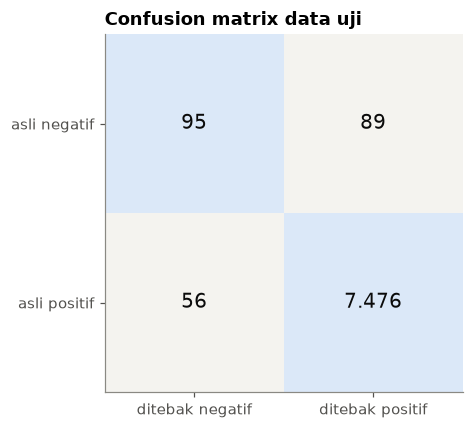

In [15]:
label_urut = ["negatif", "positif"]
matriks = confusion_matrix(y_uji, prediksi_uji, labels=label_urut)

fig, ax = plt.subplots(figsize=(4.8, 4))
ax.imshow([[1, 0], [0, 1]], cmap=plt.matplotlib.colors.ListedColormap(["#f4f3ef", "#dbe8f8"]))
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{matriks[i, j]:,}".replace(",", "."), ha="center", va="center", fontsize=13, color="#0b0b0b")
ax.set_xticks([0, 1], labels=[f"ditebak {l}" for l in label_urut])
ax.set_yticks([0, 1], labels=[f"asli {l}" for l in label_urut])
ax.grid(False)
ax.set_title("Confusion matrix data uji")
plt.tight_layout()
plt.show()

Cara membaca confusion matrix:

- Kiri atas: ulasan negatif yang berhasil ditemukan.
- Kanan atas: ulasan negatif yang terlewat (ditebak positif).
- Kiri bawah: ulasan positif yang salah ditandai negatif (alarm palsu).
- Kanan bawah: ulasan positif yang ditebak benar.

Di data uji, F1 kelas negatif sekitar 0,57, lebih rendah dari skor cross-validation (0,62). Rentang bootstrap menunjukkan skor data uji yang wajar berkisar antara 0,50 dan 0,63, dan skor cross-validation masih berada di dalamnya. Jadi selisih ini lebih mungkin berasal dari produk mana yang kebetulan masuk data uji daripada tanda overfitting. Dengan hanya 184 ulasan negatif, satu kali uji tidak bisa memberi angka yang presisi.

Dari 184 ulasan negatif di data uji, model menemukan sekitar 52%. Dari semua ulasan yang ditandai negatif, sekitar 63% benar-benar negatif. Akurasi keseluruhan 98,1%, sedikit di atas model patokan (97,6%), tetapi perbedaan yang penting ada di kelas negatif: dari 0 menjadi sekitar separuh keluhan yang berhasil ditemukan.

## 8. Kata yang paling berpengaruh

Bobot Logistic Regression bisa dibaca langsung. Karena urutan kelasnya `["negatif", "positif"]`, bobot positif mendorong tebakan ke arah "positif", dan bobot negatif mendorong ke arah "negatif".

In [16]:
pipeline_terlatih = model_akhir.estimator_
kosakata = pipeline_terlatih.named_steps["tfidf"].get_feature_names_out()
bobot = pd.Series(pipeline_terlatih.named_steps["model"].coef_[0], index=kosakata)

print("Jumlah kata dan pasangan kata di kosakata:", len(kosakata))
paling_negatif = bobot.nsmallest(15)
paling_positif = bobot.nlargest(15)

Jumlah kata dan pasangan kata di kosakata: 19583


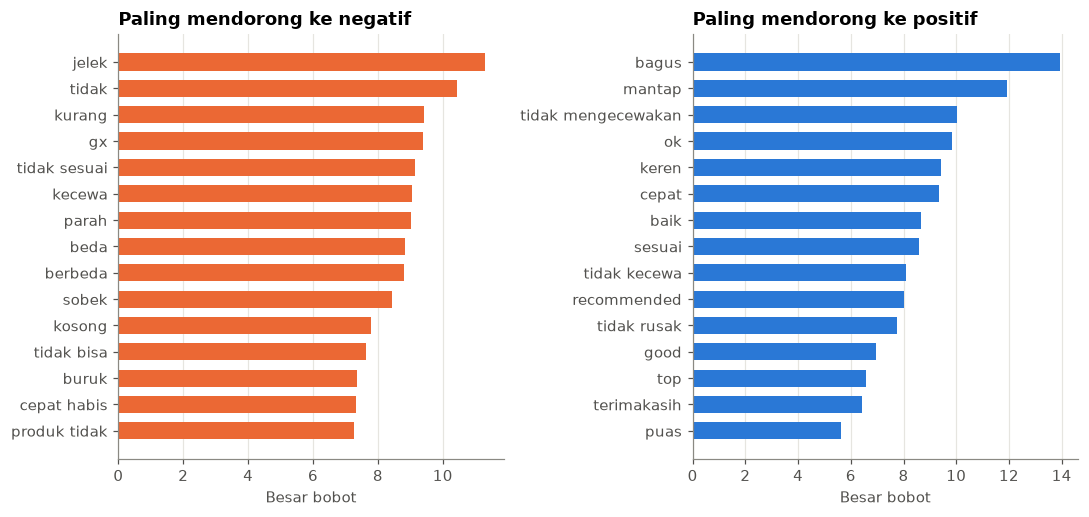

In [17]:
fig, (kiri, kanan) = plt.subplots(1, 2, figsize=(10, 4.8))
for ax, data, warna, judul in [
    (kiri, paling_negatif.abs(), ORANYE, "Paling mendorong ke negatif"),
    (kanan, paling_positif, BIRU, "Paling mendorong ke positif"),
]:
    data = data.sort_values()
    ax.barh(data.index, data.values, color=warna, height=0.65)
    ax.set_title(judul)
    ax.set_xlabel("Besar bobot")
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Sebagian besar kata yang dipelajari model masuk akal:

- Ke arah negatif: "jelek", "tidak", "kurang", "tidak sesuai", "kecewa", "parah", "sobek", dan "buruk".
- Ke arah positif: "bagus", "mantap", "ok", "keren", "cepat", "sesuai", dan "recommended".

Yang paling menarik adalah pasangan kata "tidak mengecewakan", "tidak kecewa", dan "tidak rusak", yang justru mendorong kuat ke arah positif. Kata "tidak" sendiri mendorong ke negatif, tetapi berkat bigram, model belajar bahwa "tidak" yang diikuti kata negatif membalik maknanya. Ini bukti `ngram_range=(1, 2)` memang berguna.

Kata "gx" juga masuk daftar negatif teratas. "gx" adalah singkatan "gak" yang belum ada di kamus normalisasi `src/teks.py`, sehingga model mempelajarinya sebagai kata tersendiri, terpisah dari "tidak". Kamus normalisasi masih bisa dilengkapi.

Ada juga beberapa kata yang kurang masuk akal, seperti "biji" dan "kmaren" yang ke arah negatif, atau "kurir" yang ke arah positif. Kata-kata ini kemungkinan kebetulan muncul di beberapa ulasan tertentu saja, dan model dengan `C` besar cenderung ikut menghafal kebetulan seperti ini. Ini salah satu bentuk overfitting kecil yang biasa terjadi.

## 9. Analisis kesalahan

Melihat contoh yang salah ditebak membantu memahami batas kemampuan model.

In [18]:
hasil_uji = pd.DataFrame({"teks": df.loc[X_uji.index, "teks"], "asli": y_uji, "tebakan": prediksi_uji})

print("Negatif yang terlewat (ditebak positif):")
with pd.option_context("display.max_colwidth", 110):
    display(hasil_uji[(hasil_uji["asli"] == "negatif") & (hasil_uji["tebakan"] == "positif")].sample(8, random_state=1))

Negatif yang terlewat (ditebak positif):


,teks,asli,tebakan
18176,"Makasih ya mas sudah salah kirim, next time dicek dulu ya😘",negatif,positif
27455,Ghkljhvghhjjjkmlmbhhuuiookhgffddderyhhhjjjjkkk,negatif,positif
15881,waduh baru sekali kena air langsung masuk deh air nya katanya kuat air dan saya cuma pake sambil wudhu apa...,negatif,positif
15900,saya kecewa gan... baru pakai sekali knapa lansung berembun... setelah kena air,negatif,positif
33258,Di Catatan penjual berat 6 kg dgn harapan net lumayan bagus nyatanya cuma 4kg berarti bahannya tipis ...,negatif,positif
31107,"Untuk produk ini saya kasi 2 bintang saja krna celananya tdk sesuai yg di foto, celanax kependekan tdk di ...",negatif,positif
18171,"Packing rapi ,tapi barang ķotor ga sesuai merk dideskripsi,berdebu,ada yang bocel atau lecet analaognya\n....",negatif,positif
10805,"Kecewa, Sepatu baru dipake jalan 1x jangka waktu 1 jam tali putus... \nbahan kulit juga tidak mulus ada lem2",negatif,positif


In [19]:
print("Positif yang ditandai negatif (alarm palsu):")
with pd.option_context("display.max_colwidth", 110):
    display(hasil_uji[(hasil_uji["asli"] == "positif") & (hasil_uji["tebakan"] == "negatif")].sample(8, random_state=1))

Positif yang ditandai negatif (alarm palsu):


,teks,asli,tebakan
29407,"barang ok,, hanya saja kurir grabnya meras masa minta uang lagi 20 rb alesan titik mapnya kga sama,, padah...",positif,negatif
2955,ko ga ada contoh conversationnya?,positif,negatif
29965,"barang sdh terima, segera ditest kalau catridge lama habis.",positif,negatif
8557,Barang kosong..tp refun udah diterima...,positif,negatif
12328,"sebenernya ukuran untuk sepatu ini tidak sesuai yg saya pesan,karena katanya kosong,sebelumnya penjual men...",positif,negatif
13852,"Setelah 3 hari jam nya rusak...terkadang dia jalan, terkadang mati sendiri...tolong bantuannya agar jam ts...",positif,negatif
15975,Diameteeeer&#39;y kecil bngt,positif,negatif
18107,"Pengirimannya lambat,packingnya gak rapi waktu nerima sdh terbuka,kualitasnya lumayanlah",positif,negatif


Pola kesalahan yang umum:

- Keluhan tanpa kata negatif yang jelas, misalnya "baru sekali kena air langsung masuk deh airnya". Pembeli menceritakan masalahnya, tetapi tidak memakai kata seperti "rusak" atau "kecewa".
- Ulasan campuran yang memuat pujian dan keluhan sekaligus, misalnya "packing rapi, tapi barang kotor". Kata pujian membuat model condong ke positif.
- Sarkasme, misalnya "makasih ya mas sudah salah kirim". Kata "makasih" mendorong ke positif, padahal maksudnya menyindir.
- Label noise dari arah sebaliknya. Beberapa ulasan bintang 4 atau 5 isinya jelas keluhan, misalnya "setelah 3 hari jamnya rusak" atau "pengirimannya lambat, packingnya gak rapi". Model menebak negatif, dan tebakan itu sebenarnya lebih masuk akal daripada labelnya. Bagian 10 membahas ini lebih jauh.
- Teks yang tidak bermakna, misalnya deretan huruf acak. Tidak ada model teks yang bisa menebak bintangnya.

In [20]:
# Mencoba kalimat baru. Teksnya ditulis dalam bentuk yang sudah bersih,
# karena model menerima hasil fungsi bersihkan_teks dari notebook 05.
kalimat = pd.Series([
    "barang bagus pengiriman cepat",
    "barang tidak sesuai kecewa",
    "barang bagus tapi pengiriman lama",
    "tidak jelek kok",
    "ukurannya kekecilan",
])
peluang_negatif = model_akhir.predict_proba(kalimat)[:, list(model_akhir.classes_).index("negatif")]
pd.DataFrame({"kalimat": kalimat, "tebakan": model_akhir.predict(kalimat), "peluang_negatif": peluang_negatif.round(3)})

,kalimat,tebakan,peluang_negatif
0,barang bagus pengiriman cepat,positif,0.000
1,barang tidak sesuai kecewa,negatif,1.000
2,barang bagus tapi pengiriman lama,positif,0.011
3,tidak jelek kok,negatif,0.999
4,ukurannya kekecilan,positif,0.196


Contoh "tidak jelek kok" menunjukkan keterbatasan model berbasis kata. Pasangan "tidak jelek" terlalu jarang muncul di data latih, sehingga model hanya melihat kata "tidak" dan "jelek" yang keduanya bobotnya negatif. Berbeda dengan "tidak kecewa" yang cukup sering muncul dan sudah dipelajari sebagai positif. Contoh "ukurannya kekecilan" juga lolos sebagai positif karena tidak ada kata negatif yang jelas. Model yang memahami susunan kalimat, seperti IndoBERT, bisa menangani kasus ini lebih baik, tetapi jauh lebih berat untuk dilatih dan dijalankan.

## 10. Kenapa skornya mentok

Bagian 5 dan 6 sudah mencoba pengaturan model. Di luar notebook ini, beberapa varian lain juga sudah diuji dengan cross-validation yang sama: `C` sampai 1000, fitur potongan huruf (`analyzer="char_wb"`) yang diharapkan bisa menangkap salah ketik, dan gabungan fitur kata dan huruf. Tidak ada yang lebih baik dari model di atas. Pertanyaan berikutnya: apakah skor bisa dinaikkan dengan mengganti model atau fitur, atau batasnya ada di data? Bagian ini menguji tiga kemungkinan, semuanya dengan cross-validation di data latih.

Untuk membandingkan, dipakai F1 pada ambang terbaik, dihitung dari prediksi cross-validation. Angka ini sedikit optimis karena ambangnya dipilih dari data yang sama, tetapi cukup adil untuk membandingkan beberapa cara, karena semua cara dinilai dengan aturan yang sama.

In [21]:
def f1_ambang_terbaik(y_asli, peluang_negatif):
    """F1 kelas negatif pada ambang yang paling menguntungkan."""
    precision, recall, _ = precision_recall_curve(y_asli == "negatif", peluang_negatif)
    f1 = 2 * precision * recall / np.clip(precision + recall, 1e-9, None)
    return f1[:-1].max()


print(f"F1 pada ambang terbaik, model akhir: {f1_ambang_terbaik(y_latih, peluang_cv[:, kolom_negatif]):.3f}")

F1 pada ambang terbaik, model akhir: 0.628


### 10a. Apakah pembagian acak membuat skor terlihat lebih bagus?

Model yang sama dinilai ulang dengan cross-validation acak, yaitu tanpa memperhatikan produk, lalu dibandingkan dengan cross-validation per produk.

In [22]:
cv_acak = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
peluang_acak = cross_val_predict(
    buat_pipeline(C=C_terbaik, class_weight=cw_terbaik),
    X_latih, y_latih, cv=cv_acak, method="predict_proba", n_jobs=2,
)[:, kolom_negatif]

pd.DataFrame({
    "cara membagi": ["acak", "per produk"],
    "F1 ambang terbaik": [f1_ambang_terbaik(y_latih, peluang_acak), f1_ambang_terbaik(y_latih, peluang_cv[:, kolom_negatif])],
}).round(3)

,cara membagi,F1 ambang terbaik
0,acak,0.637
1,per produk,0.628


Selisihnya kecil: sekitar 0,64 dengan pembagian acak dan 0,63 dengan pembagian per produk. Di data ini, model hanya sedikit terbantu oleh ulasan dari produk yang sama. Pembagian per produk tetap dipakai karena lebih sesuai dengan cara model dipakai di dashboard, dan konsisten dengan notebook 08.

Versi awal notebook ini, yang membagi data secara acak, mendapat F1 0,62 di data uji. Versi ini mendapat 0,57. Kedua angka masih berada di rentang bootstrap bagian 7 (0,50 sampai 0,63), jadi perbedaannya lebih banyak dipengaruhi isi data uji daripada perubahan cara membagi.

### 10b. Apakah model kekurangan data?

Model dilatih ulang dengan 25%, 50%, dan 75% data latih. Kalau skornya masih naik sampai 100%, berarti menambah ulasan berlabel masih akan membantu. Kalau skornya sudah mendatar, menambah data tidak banyak berguna. Setiap porsi diulang tiga kali dengan sampel berbeda, lalu dirata-rata.

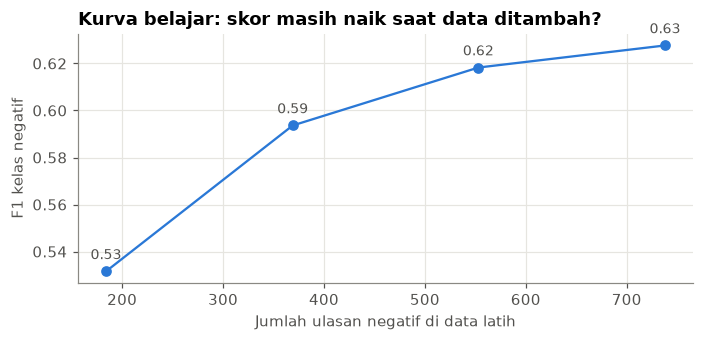

,porsi data latih,ulasan negatif,F1
0,0.25,184,0.532
1,0.50,369,0.594
2,0.75,553,0.618
3,1.00,738,0.628


In [23]:
hasil_kurva = []
for porsi in [0.25, 0.5, 0.75, 1.0]:
    skor = []
    for ulang in range(3 if porsi < 1 else 1):
        if porsi < 1:
            pilih, _ = train_test_split(np.arange(len(X_latih)), train_size=porsi, stratify=y_latih, random_state=ulang)
        else:
            pilih = np.arange(len(X_latih))
        X_s, y_s, g_s = X_latih.iloc[pilih], y_latih.iloc[pilih], produk_latih.iloc[pilih]
        lipatan = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42).split(X_s, y_s, groups=g_s)
        p = cross_val_predict(buat_pipeline(C=C_terbaik, class_weight=cw_terbaik), X_s, y_s,
                              cv=list(lipatan), method="predict_proba", n_jobs=2)[:, kolom_negatif]
        skor.append(f1_ambang_terbaik(y_s, p))
    hasil_kurva.append({"porsi data latih": porsi, "ulasan negatif": int((y_latih == "negatif").sum() * porsi), "F1": np.mean(skor)})

kurva = pd.DataFrame(hasil_kurva)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(kurva["ulasan negatif"], kurva["F1"], marker="o", color=BIRU)
for _, baris in kurva.iterrows():
    ax.annotate(f"{baris['F1']:.2f}", (baris["ulasan negatif"], baris["F1"]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9, color=TEKS)
ax.set_xlabel("Jumlah ulasan negatif di data latih")
ax.set_ylabel("F1 kelas negatif")
ax.set_title("Kurva belajar: skor masih naik saat data ditambah?")
plt.tight_layout()
plt.show()
kurva.round(3)

Skor masih naik setiap kali data ditambah, dari sekitar 0,53 dengan 184 ulasan negatif menjadi sekitar 0,63 dengan 738 ulasan negatif. Namun kenaikannya terus mengecil: sekitar +0,06, lalu +0,02, lalu hanya +0,01. Garisnya mulai mendatar. Menambah ulasan negatif berlabel masih membantu sedikit, tetapi kemungkinan tidak akan menaikkan skor secara drastis. Penyebab yang lebih besar dibahas di bagian 10c.

### 10c. Seberapa sering label tidak cocok dengan isi ulasan?

Label dibuat dari bintang: bintang 1-2 negatif, bintang 4-5 positif. Masalahnya, bintang tidak selalu cocok dengan isi ulasan. Untuk melihat seberapa sering, dipakai lagi peluang negatif dari cross-validation di bagian 6. Setiap ulasan dinilai oleh model yang tidak melihat ulasan itu saat dilatih.

Yang dilihat adalah kesalahan yang paling yakin: ulasan berbintang 4-5 yang peluang negatifnya paling tinggi, dan ulasan berbintang 1-2 yang peluang negatifnya paling rendah.

In [24]:
yakin = pd.DataFrame({
    "teks": df.loc[X_latih.index, "teks"].str.replace("\n", " "),
    "rating": df.loc[X_latih.index, "rating"],
    "label": y_latih,
    "peluang_negatif": peluang_cv[:, kolom_negatif],
})

print("Berlabel positif (bintang 4-5), tetapi model sangat yakin negatif:")
with pd.option_context("display.max_colwidth", 100):
    display(yakin[yakin["label"] == "positif"].nlargest(12, "peluang_negatif")[["rating", "peluang_negatif", "teks"]].round(3))

Berlabel positif (bintang 4-5), tetapi model sangat yakin negatif:


,rating,peluang_negatif,teks
16679,4,1.000,ga daper stempel kurang oyy
4763,4,1.000,Parah...jelek bngt speaker gak bs.org nelp gak kdgran.alrm jg gak fungsi
4779,4,1.000,Tidak sesuai ....supercopy
6053,4,0.998,Kecewa..!Barang rusak mau retur penjual minta kita yg bayar ongkir pp...🙁🙁🙁
8302,4,0.996,Payah...spekernya mati sebelah..
10190,4,0.995,"Barang tdk rekomen, ukuran tdk sesuai"
28105,5,0.992,Kurang bagus. Kaya bekas. Udah jelek. Tp isi full
3747,4,0.990,Tutupnya ada yang pecah sehingga tidak bisa ditutup
27230,5,0.989,"bos barang kmrin blm sampai 1 bulan kok udh drop batrai nya, gk bsa ngecas sama sekali....0% j w..."
6322,4,0.979,Barang yg di kirim rusak ga bisa di pakai


In [25]:
print("Berlabel negatif (bintang 1-2), tetapi model sangat yakin positif:")
with pd.option_context("display.max_colwidth", 100):
    display(yakin[yakin["label"] == "negatif"].nsmallest(12, "peluang_negatif")[["rating", "peluang_negatif", "teks"]].round(3))

negatif_latih = yakin[yakin["label"] == "negatif"]
hampir_pasti_positif = (negatif_latih["peluang_negatif"] < 0.05).sum()
print(f"Ulasan negatif dengan peluang negatif di bawah 5%: {hampir_pasti_positif} dari {len(negatif_latih)} "
      f"({hampir_pasti_positif / len(negatif_latih):.0%})")

Berlabel negatif (bintang 1-2), tetapi model sangat yakin positif:


,rating,peluang_negatif,teks
17697,2,0.0,Mantapppp.............................
8366,1,0.0,Thanks..........................................
5702,1,0.0,Barang sesuai dengan pesanan
20822,2,0.0,"Trims, joystick sudah sampe (pengiriman cepat), seller fast response."
34360,1,0.0,"barangnya bagus, tapi respon agak lama..."
7332,2,0.0,"Barangnya bagus, smg awet dehh ni barang"
33752,2,0.0,Fast Respon ! Good job.............................................................
33377,1,0.0,makasih barang sudah saya terima .......
34379,2,0.0,"barang nya bagus,tidak mengecewakan"
33761,2,0.0,barang sudah diterima dg baik. maaf reviewnya telat


Ulasan negatif dengan peluang negatif di bawah 5%: 138 dari 738 (19%)


Kedua tabel di atas hanya menampilkan kasus yang paling ekstrem, jadi belum bisa dipakai untuk menyimpulkan seberapa sering label benar-benar keliru. Untuk itu, dua kelompok ulasan diperiksa manual dengan membaca teksnya satu per satu, lalu dicatat apakah ulasannya berisi keluhan. Keluhan ringan seperti "agak telat" tetap dihitung sebagai keluhan. Hasilnya disimpan di `Dataset/manual/cek_label_sentimen.csv`.

- `negatif_terlewat`: semua ulasan bintang 1-2 di data latih yang peluang negatifnya di bawah 5%.
- `alarm_palsu`: 60 sampel acak dari ulasan bintang 4-5 yang ditebak negatif pada ambang akhir.

In [26]:
cek_label = pd.read_csv("../Dataset/manual/cek_label_sentimen.csv")
ringkas_cek = cek_label.groupby("kelompok")["berisi_keluhan"].agg(jumlah="size", berisi_keluhan="sum")
ringkas_cek["persen_berisi_keluhan"] = (ringkas_cek["berisi_keluhan"] / ringkas_cek["jumlah"] * 100).round(0)
ringkas_cek

,jumlah,berisi_keluhan,persen_berisi_keluhan
kelompok,,,
alarm_palsu,60,37,62.0
negatif_terlewat,138,106,77.0


In [27]:
# Seberapa besar precision yang terukur dipengaruhi label yang keliru?
tebakan_negatif = yakin["peluang_negatif"] >= model_akhir.best_threshold_
benar_negatif = (tebakan_negatif & (yakin["label"] == "negatif")).sum()
alarm_palsu = (tebakan_negatif & (yakin["label"] == "positif")).sum()
porsi_keluhan = cek_label.loc[cek_label["kelompok"] == "alarm_palsu", "berisi_keluhan"].mean()

print(f"Ditebak negatif: {benar_negatif + alarm_palsu} | label negatif: {benar_negatif} | label positif (alarm palsu): {alarm_palsu}")
print(f"Precision terukur                        : {benar_negatif / (benar_negatif + alarm_palsu):.0%}")
print(f"Precision kalau alarm palsu yang berisi keluhan dihitung benar (perkiraan): "
      f"{(benar_negatif + porsi_keluhan * alarm_palsu) / (benar_negatif + alarm_palsu):.0%}")

Ditebak negatif: 637 | label negatif: 430 | label positif (alarm palsu): 207
Precision terukur                        : 68%
Precision kalau alarm palsu yang berisi keluhan dihitung benar (perkiraan): 88%


Hasil pemeriksaan manual:

- **Di sisi negatif, label yang keliru sedikit.** Dari ulasan bintang 1-2 yang paling yakin dilewatkan model, hanya sekitar seperempat yang memang tidak berisi keluhan, misalnya "Mantap", "Thanks", dan "paket udah keterima terimakasih". Jumlahnya sekitar 32 dari 738 ulasan negatif di data latih, atau sekitar 4%. Angka ini sejalan dengan perkiraan kasar di notebook 04.
- **Sebagian besar keluhan yang terlewat adalah keluhan sungguhan.** Sekitar tiga perempatnya berisi keluhan yang gagal dikenali model, misalnya "Pengiriman lama", "Deker nya kekecilan", dan "Barang sampai dalam keadaan basah". Ulasan seperti ini umumnya pendek atau memakai kata keluhan yang jarang muncul di data latih. Karena 97,6% data latih positif, model punya kecenderungan awal yang kuat ke arah positif, dan satu kata keluhan yang jarang sering tidak cukup untuk membalik tebakan.
- **Di sisi positif, label yang keliru banyak.** Sekitar 62% alarm palsu ternyata memang berisi keluhan walaupun diberi bintang 4 atau 5, misalnya "Kainnya kurang kuat, baru dipakai sekali sobek". Di sini tebakan model benar, tetapi dihitung salah. Kalau proporsi ini berlaku untuk semua alarm palsu, precision model yang sebenarnya sekitar 88%, jauh di atas 68% yang terukur. Angka ini perkiraan kasar, karena hanya didasarkan pada 60 sampel.
- Alarm palsu yang benar-benar salah banyak berupa negasi dari kata negatif, seperti "ga prnah kecewa" atau "tidak ada yang error atau cacat". Bigram membantu untuk pasangan yang sering muncul seperti "tidak kecewa", tetapi tidak untuk variasi yang jarang.

### Kesimpulan bagian 10

| Kemungkinan penyebab | Hasil | Artinya |
|---|---|---|
| Pengaturan model kurang tepat | `C` lebih besar, fitur huruf, dan gabungan fitur tidak lebih baik | Model sudah optimal untuk pendekatan TF-IDF |
| Pembagian acak membuat skor terlalu optimis | Selisih hanya sekitar 0,01 | Pengaruhnya kecil |
| Data kurang | Skor masih naik saat data ditambah, tetapi kenaikannya mengecil | Menambah data membantu sedikit, bukan penyebab utama |
| Label tidak cocok dengan isi | Di sisi negatif hanya sekitar 4% label yang keliru. Di sisi positif, sekitar 62% alarm palsu ternyata keluhan berbintang 4-5 | Menekan precision yang terukur. Precision sebenarnya kemungkinan jauh lebih tinggi |
| Keterbatasan model berbasis kata | Sekitar tiga perempat keluhan yang paling yakin dilewatkan adalah keluhan sungguhan | Penyebab utama recall rendah: keluhan pendek, kata keluhan yang jarang, dan negasi |

Jadi skor model tertahan oleh dua hal sekaligus. Label yang keliru membuat precision terlihat lebih rendah dari kenyataan, sedangkan keterbatasan model berbasis kata membuat banyak keluhan terlewat.

Dua langkah yang paling menjanjikan:

1. Membuat data uji dengan label manual berdasarkan isi ulasan, bukan bintangnya, supaya skor mencerminkan kemampuan model yang sebenarnya.
2. Menangani negasi dan keluhan pendek, misalnya dengan menggabungkan "tidak" dengan kata sesudahnya menjadi satu token, atau memakai model yang memahami susunan kalimat seperti IndoBERT.

## 11. Simpan model

Model disimpan dengan `joblib` ke folder `models/`. Yang disimpan adalah seluruh rangkaian: TF-IDF, Logistic Regression, dan ambang keputusannya. Jadi di dashboard cukup memuat satu file ini, lalu memanggil `predict`.

Hal penting saat memakai model ini: teks yang diberikan ke model harus dibersihkan dulu dengan fungsi `bersihkan_teks` yang sama persis seperti di notebook 05. Kalau pembersihannya berbeda, misalnya "gk" tidak diubah menjadi "tidak", model akan menerima kata yang tidak pernah dilihatnya saat belajar.

Ringkasan skor juga disimpan dalam file JSON, supaya dashboard bisa menampilkan seberapa akurat model ini.

In [28]:
folder_model = Path("../models")
folder_model.mkdir(exist_ok=True)

# Daftar lipatan cross-validation (cv) ikut tersimpan di dalam model dan menambah sekitar 1,2 MB,
# padahal tidak dipakai saat memprediksi. Karena itu dikosongkan sebelum disimpan.
model_akhir.set_params(cv=None)
joblib.dump(model_akhir, folder_model / "sentimen.joblib")

laporan = classification_report(y_uji, prediksi_uji, output_dict=True)
metrik = {
    "model": "TF-IDF (1-2 gram) + Logistic Regression",
    "C": C_terbaik,
    "class_weight": cw_terbaik,
    "ambang_peluang_negatif": round(float(model_akhir.best_threshold_), 4),
    "data_latih": int(len(X_latih)),
    "data_uji": int(len(X_uji)),
    "uji_precision_negatif": round(laporan["negatif"]["precision"], 4),
    "uji_recall_negatif": round(laporan["negatif"]["recall"], 4),
    "uji_f1_negatif": round(laporan["negatif"]["f1-score"], 4),
    "uji_akurasi": round(laporan["accuracy"], 4),
}
(folder_model / "sentimen_metrik.json").write_text(json.dumps(metrik, indent=2))
metrik

{'model': 'TF-IDF (1-2 gram) + Logistic Regression',
 'C': 30,
 'class_weight': None,
 'ambang_peluang_negatif': 0.303,
 'data_latih': 30869,
 'data_uji': 7716,
 'uji_precision_negatif': 0.6291,
 'uji_recall_negatif': 0.5163,
 'uji_f1_negatif': 0.5672,
 'uji_akurasi': 0.9812}

In [29]:
# Pastikan model yang tersimpan bisa dimuat ulang dan memberi hasil yang sama
model_muat = joblib.load(folder_model / "sentimen.joblib")
assert (model_muat.predict(X_uji) == prediksi_uji).all()
model_muat.predict(pd.Series(["barang tidak sesuai kecewa"]))

array(['negatif'], dtype=object)

## Ringkasan

| Langkah | F1 negatif (cross-validation per produk) |
|---|---|
| Model patokan (selalu positif) | 0 |
| Logistic Regression standar | sekitar 0,36 |
| Dengan class_weight balanced | sekitar 0,52 |
| GridSearchCV (C=30) | sekitar 0,59 |
| Ambang disesuaikan | sekitar 0,62 |

Di data uji, model akhir mendapat F1 kelas negatif sekitar 0,57 (rentang bootstrap 0,50 sampai 0,63), dengan precision sekitar 63% dan recall sekitar 52%. Data latih dan data uji dibagi per produk, jadi skor ini mencerminkan kemampuan model menilai ulasan dari produk yang belum pernah dilihatnya.

Keterbatasan:

- Label berasal dari rating. Di sisi negatif hanya sekitar 4% label yang keliru, tetapi sekitar 62% alarm palsu ternyata keluhan berbintang 4-5. Akibatnya precision yang terukur lebih rendah dari kenyataan (bagian 10c).
- Model berbasis kata tidak memahami susunan kalimat. Keluhan pendek, kata keluhan yang jarang, sarkasme, dan negasi seperti "tidak jelek" sering salah ditebak. Ini penyebab utama recall yang rendah.
- Ulasan negatif di data latih didominasi kategori handphone, dan semua ulasan berasal dari tahun 2019 dan 158 toko. Model mungkin kurang akurat untuk kategori atau gaya bahasa yang berbeda.